In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 提取数据
# MC和CQ_max数据
filename_path1 = r"C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\saved_studies\CQ_MC_Pareto_beta50_20250825_121711_pareto.csv"
# CQ_-11和任务表现数据
filename_path2 = r"C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\CQ_MC_Pareto_beta50_20250825_121711_normalized-11_pareto.csv"
# CQ_01数据
filename_path3 = r"C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\CQ_MC_Pareto_beta50_20250825_121711_pareto_normalized01.csv"
# CQ_without数据
filename_path4 = r"C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\CQ_MC_Pareto_beta50_20250825_121711_pareto_without.csv"

def collect_data(filename_path):
    # 读取pareto文件
    data = pd.read_csv(filename_path)
    return data  # 需要返回数据，否则默认返回None

data1 = collect_data(filename_path1)
data2 = collect_data(filename_path2)
data3 = collect_data(filename_path3)
data4 = collect_data(filename_path4)


import ast
MC = data1["values"].apply(lambda x: ast.literal_eval(x)[1])

CQ_max = data1["values"].apply(lambda x: ast.literal_eval(x)[0])

CQ_minmax = data2["kr_threshold"]-data2['gr_threshold'] 

CQ_01 = data3["kr_threshold"]-data3['gr_threshold'] 

CQ_without = data4["kr_threshold"]-data4['gr_threshold'] 

nrmse = data2['narma10_nrmse']

error_rate = (1-np.array(data2['ti46_accuracy']))*100

# 提取出所有点的trials
trials = data2['trial_number']

print(trials)


0      33
1      34
2      60
3      65
4      71
5      74
6      75
7      78
8      87
9      90
10     93
11    105
12    106
13    119
14    120
15    127
16    139
17    144
18    157
19    168
20    174
21    176
22    202
23    204
24    211
25    247
26    250
27    252
28    267
29    291
30    294
31    295
32    310
33    311
34    317
35    320
36    329
37    336
38    337
39    341
40    351
41    352
42    364
43    367
44    376
45    382
46    393
Name: trial_number, dtype: int64


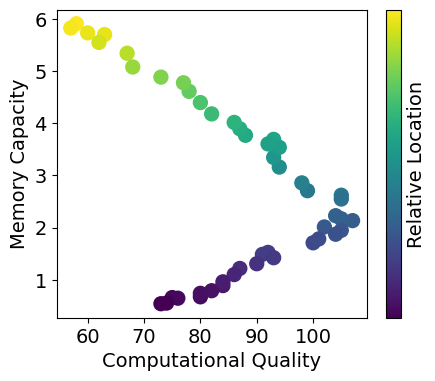

In [8]:
plt.figure(figsize=(5, 4))
plt.scatter(CQ_without, MC, c=MC, cmap='viridis', s=100)
cbar = plt.colorbar(label='Relative Location', ticks=[])
cbar.set_label('Relative Location', fontsize=14)
plt.xlabel('Computational Quality', fontsize=14)
plt.ylabel('Memory Capacity', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

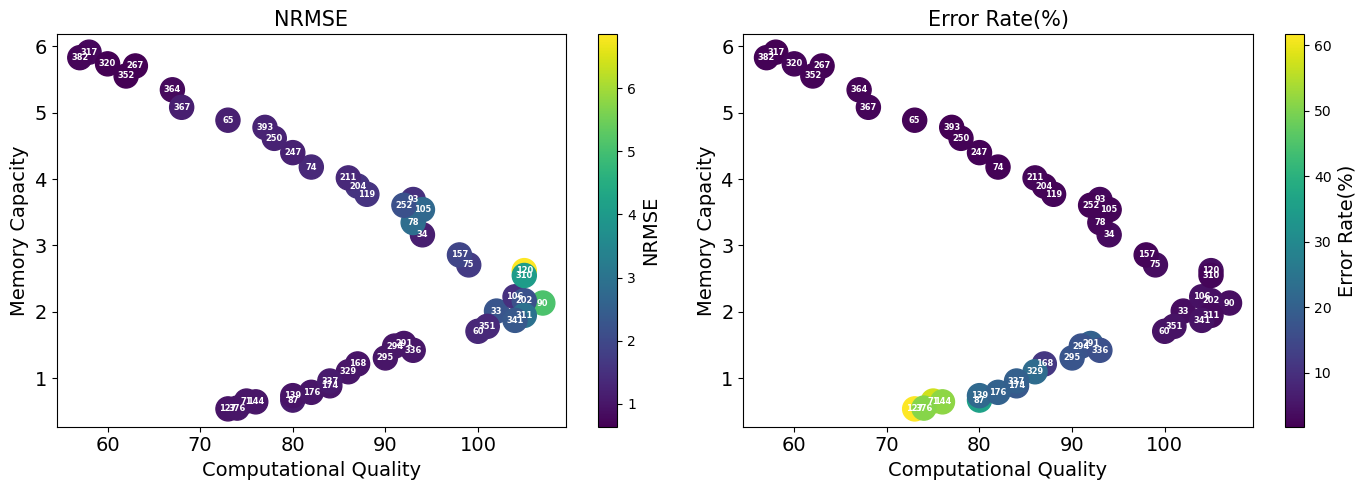

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 子图1: NRMSE
sc1 = axs[0].scatter(CQ_without, MC, c=nrmse, cmap='viridis', s=300)
cbar1 = plt.colorbar(sc1, ax=axs[0])
cbar1.set_label('NRMSE', fontsize=14)
axs[0].set_xlabel('Computational Quality', fontsize=14)
axs[0].set_ylabel('Memory Capacity', fontsize=14)
axs[0].tick_params(axis='both', labelsize=14)
# 标注trials
for x, y, trial in zip(CQ_without, MC, trials):
    axs[0].text(x, y, str(trial), fontsize=6, ha='center', va='center', color='white', fontweight='bold')
axs[0].set_title('NRMSE', fontsize=15)

# 子图2: Error Rate
sc2 = axs[1].scatter(CQ_without, MC, c=error_rate, cmap='viridis', s=300)
cbar2 = plt.colorbar(sc2, ax=axs[1])
cbar2.set_label('Error Rate(%)', fontsize=14)
axs[1].set_xlabel('Computational Quality', fontsize=14)
axs[1].set_ylabel('Memory Capacity', fontsize=14)
axs[1].tick_params(axis='both', labelsize=14)
# 标注trials
for x, y, trial in zip(CQ_without, MC, trials):
    axs[1].text(x, y, str(trial), fontsize=6, ha='center', va='center', color='white', fontweight='bold')
axs[1].set_title('Error Rate(%)', fontsize=15)

plt.tight_layout()
plt.show()

C:\Users\Chen\AppData\Local\Temp\ipykernel_44964\3490392596.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nrmse[nrmse>1]=1.1


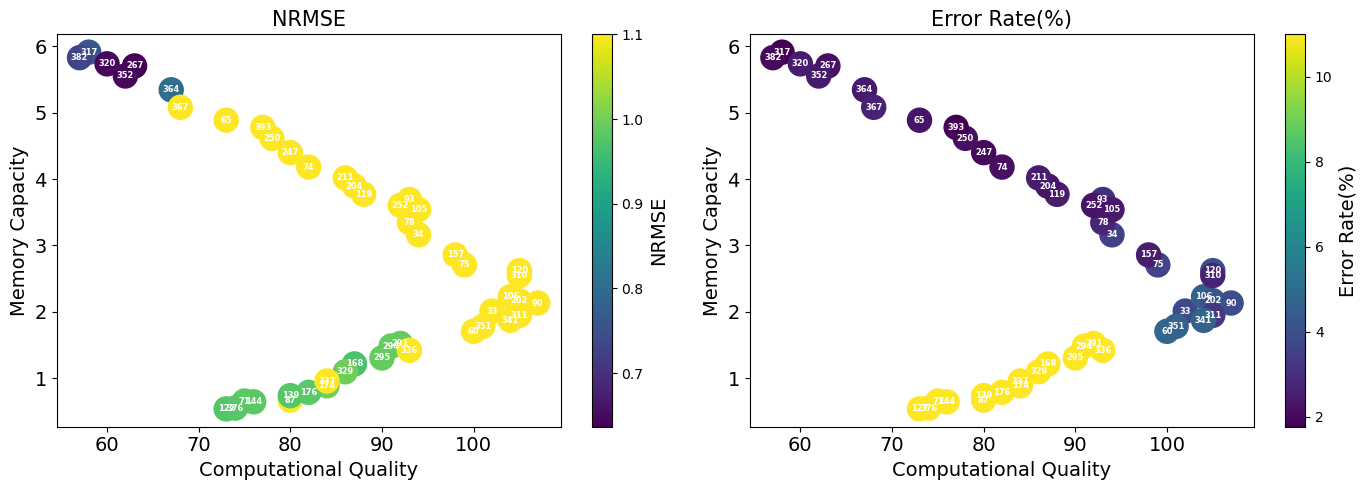

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

nrmse[nrmse>1]=1.1

error_rate[error_rate > 10] = 11

# 子图1: NRMSE
sc1 = axs[0].scatter(CQ_without, MC, c=nrmse, cmap='viridis', s=300)
cbar1 = plt.colorbar(sc1, ax=axs[0])
cbar1.set_label('NRMSE', fontsize=14)
axs[0].set_xlabel('Computational Quality', fontsize=14)
axs[0].set_ylabel('Memory Capacity', fontsize=14)
axs[0].tick_params(axis='both', labelsize=14)
# 标注trials
for x, y, trial in zip(CQ_without, MC, trials):
    axs[0].text(x, y, str(trial), fontsize=6, ha='center', va='center', color='white', fontweight='bold')
axs[0].set_title('NRMSE', fontsize=15)

# 子图2: Error Rate
sc2 = axs[1].scatter(CQ_without, MC, c=error_rate, cmap='viridis', s=300)
cbar2 = plt.colorbar(sc2, ax=axs[1])
cbar2.set_label('Error Rate(%)', fontsize=14)
axs[1].set_xlabel('Computational Quality', fontsize=14)
axs[1].set_ylabel('Memory Capacity', fontsize=14)
axs[1].tick_params(axis='both', labelsize=14)
# 标注trials
for x, y, trial in zip(CQ_without, MC, trials):
    axs[1].text(x, y, str(trial), fontsize=6, ha='center', va='center', color='white', fontweight='bold')
axs[1].set_title('Error Rate(%)', fontsize=15)

plt.tight_layout()
plt.show()

验证思路: 第一步, 以No.267的任务表现作为基础.

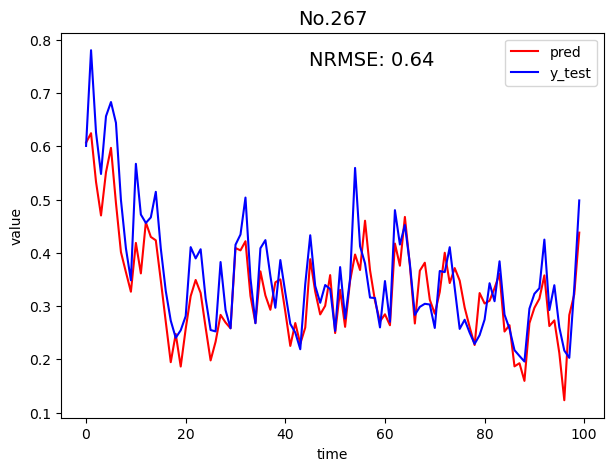

In [16]:
import pickle

with open("result_dict_beta50.pkl", "rb") as f:
    result_dict = pickle.load(f)

# 由于需要trace数据,所以只能使用result_dict.
# 在后续处理中,需要将trialnumber与result_dict中的idx对应起来.

# 提取267号的数据,其索引为28
plt.figure(figsize=(7, 5))
plt.plot(result_dict[28]['pred'][100:200],'r',label='pred')
plt.plot(result_dict[28]['y_test'][100:200],'b',label='y_test')
# 在图上打印出NRMSE
# 通过坐标控制文本位置，例如放在右上角
plt.text(70, max(result_dict[28]['y_test'][100:200]), 
         f'NRMSE: {result_dict[28]["NRMSE"]:.2f}', 
         fontsize=14, ha='right', va='top', color='black')
plt.xlabel('time')
plt.ylabel('value')
plt.title(f'No.267',fontsize=14)
plt.legend()
plt.show()





创建No.267的储层来进行随机输入测试

In [ ]:
# import necessary libraries
import os
import torch 
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle
from pathlib import Path


CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
    Path(r"/Users/vvvp./Desktop"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)





import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *

In [18]:
# 构建储层对象
class ReservoirParams:
    def __init__(self, **kwargs):
            # Reservoir parameters 
            self.h = 0.4
            self.theta_H = 90
            self.k_s_0 = 0
            self.phi = 45
            self.beta_prime = 35.13826524755751

            # Network parameters 
            self.Nvirt = 50
            self.m0 = 0.005288612874870094
            self.bias = True
            self.Nwarmup = 0
            self.verbose_repr = False

            self.params = {
                'theta': 0.34142235979698393,
                'gamma': 0.069274461903986,
                'delay_feedback': 0,
                'Nvirt': self.Nvirt,
                'length_warmup': self.Nwarmup,
                'warmup_sample': self.Nwarmup * self.Nvirt,
                'voltage_noise': False,
                'seed_voltage_noise': 1234,
                'delta_V': 0.1,
                'johnson_noise': False,
                'seed_johnson_noise': 1234,
                'mean_johnson_noise': 0.0000,
                'std_johnson_noise': 0.00001,
                'thermal_noise': False,
                'seed_thermal_noise': 1234,
                'lambda_ou': 1.0,
                'sigma_ou': 0.1
        }

            for key in ['h', 'theta_H', 'k_s_0', 'phi', 'beta_prime', 'Nvirt', 'm0', 'bias', 'Nwarmup']:
                if key in kwargs:
                    setattr(self, key, kwargs[key])

            
            if 'params' in kwargs and isinstance(kwargs['params'], dict):
                self.params.update(kwargs['params'])

    
    def update_params(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            if key in self.params:
                self.params[key] = value
            if not hasattr(self, key) and key not in self.params:
                raise AttributeError(f"ReservoirParams has no attribute or param key '{key}'")
            
    def print_params(self, verbose=False):
        if not verbose:
            print(f"ReservoirParams(h={self.h}, beta_prime={self.beta_prime}, Nvirt={self.Nvirt})")
        else:
            print(f"ReservoirParams detailed info:")
            print(f"  h = {self.h}")
            print(f"  theta_H = {self.theta_H}")
            print(f"  k_s_0 = {self.k_s_0}")
            print(f"  phi = {self.phi}")
            print(f"  beta_prime = {self.beta_prime}")
            print(f"  Nvirt = {self.Nvirt}")
            print(f"  m0 = {self.m0}")
            print(f"  bias = {self.bias}")
            print("  params dictionary:")
            for k, v in self.params.items():
                print(f"    {k}: {v}")

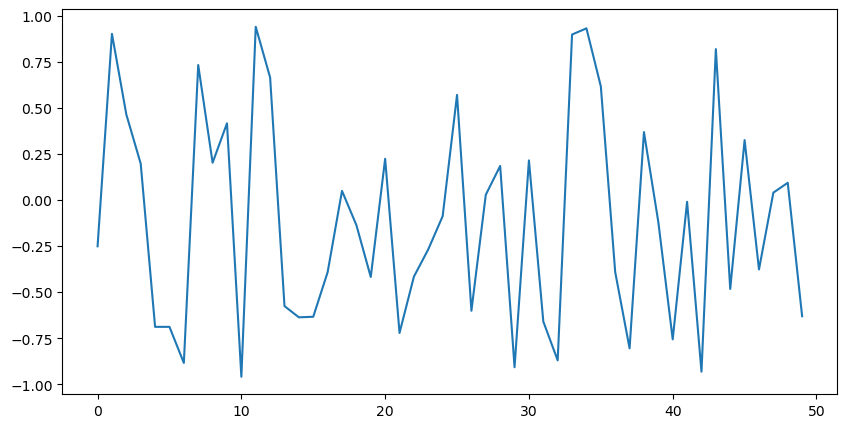

In [23]:
# 创建噪音输入
np.random.seed(42)  # 固定随机种子
noise_input = np.random.uniform(-1, 1, 500)

plt.figure(figsize=(10, 5))
plt.plot(noise_input[0:50])
plt.show()

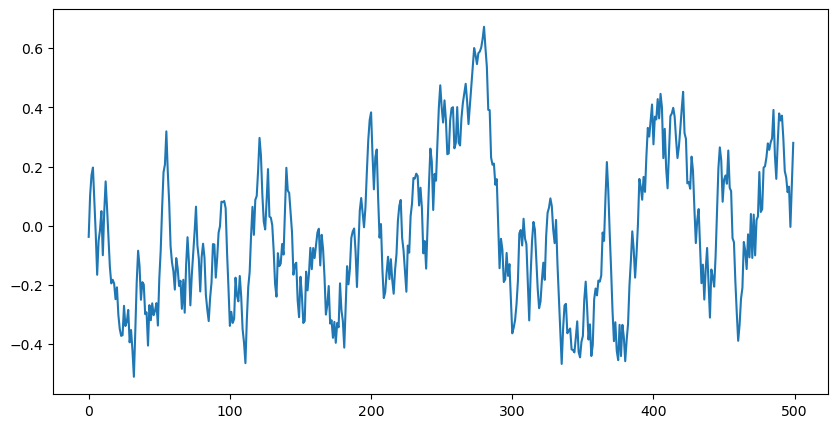

In [32]:
# set Reservoirs and RunSpncs
spn_267 = spnc_anisotropy(0.4,90,0,45,50,restart=True)

params_267 = ReservoirParams(
            h=0.4, m0=0.0516554082018051, Nvirt=1, beta_prime=50,
            params={'theta': 0.2, 'gamma': 0.0480297911638143, 'Nvirt': 1}
        )
transform_267 =  spn_267.gen_signal_slow_delayed_feedback

S_267 = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_267.Nvirt, params_267.m0, transform_267, params_267.params, fixed_mask=True, seed_mask=1234)

plt.figure(figsize=(10, 5))
plt.plot(S_267)
plt.show()

验证: 第二步,看看第二区域的储层们随着CQ和MC变化后,trace是如何变化的

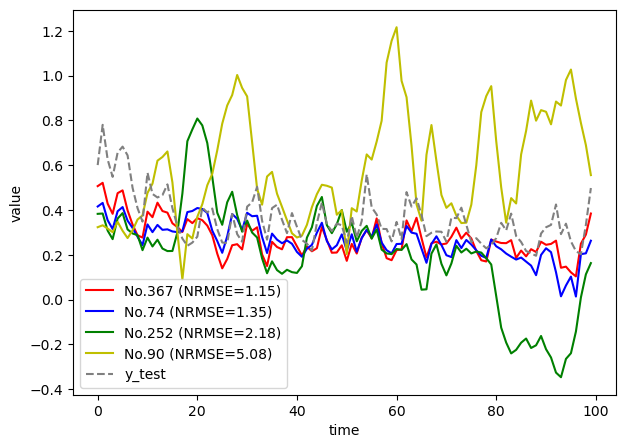

In [31]:
# 选择四个位于第二区域的储层作为测试对象,分别是No.367(43),No.74(5),No.252(27),No.90(9)
plt.figure(figsize=(7, 5))
plt.plot(result_dict[43]['pred'][100:200], 'r', label=f"No.367 (NRMSE={result_dict[43]['NRMSE']:.2f})")
plt.plot(result_dict[5]['pred'][100:200],'b',label=f'No.74 (NRMSE={result_dict[5]["NRMSE"]:.2f})')
plt.plot(result_dict[27]['pred'][100:200],'g',label=f'No.252 (NRMSE={result_dict[27]["NRMSE"]:.2f})')
plt.plot(result_dict[9]['pred'][100:200],'y',label=f'No.90 (NRMSE={result_dict[9]["NRMSE"]:.2f})')

plt.plot(result_dict[43]['y_test'][100:200], color='gray', linestyle='--', label='y_test')

plt.xlabel('time')
plt.ylabel('value')
plt.legend()
plt.show()

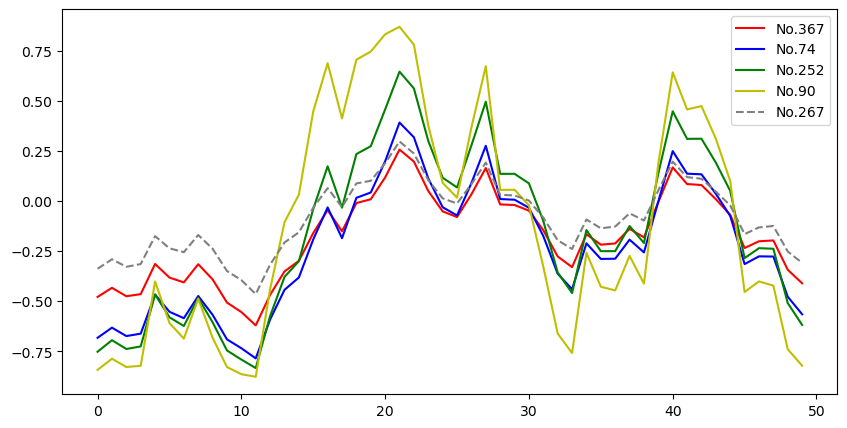

In [36]:
# set Reservoirs and RunSpncs
spn_367 = spnc_anisotropy(0.4,90,0,45,50,restart=True)

params_367 = ReservoirParams(
            h=0.4, m0=0.060112674154498, Nvirt=1, beta_prime=50,
            params={'theta': 0.2, 'gamma': 0.0578430239725703, 'Nvirt': 1}
        )
transform_367 =  spn_367.gen_signal_slow_delayed_feedback

S_367 = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_367.Nvirt, params_367.m0, transform_367, params_367.params, fixed_mask=True, seed_mask=1234)

spn_74 = spnc_anisotropy(0.4,90,0,45,50,restart=True)

params_74 = ReservoirParams(
            h=0.4, m0=0.0848363752017415, Nvirt=1, beta_prime=50,
            params={'theta': 0.2, 'gamma': 0.0674087689787963, 'Nvirt': 1}
        )
transform_74 =  spn_74.gen_signal_slow_delayed_feedback

S_74 = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_74.Nvirt, params_74.m0, transform_74, params_74.params, fixed_mask=True, seed_mask=1234)

spn_252 = spnc_anisotropy(0.4,90,0,45,50,restart=True)

params_252 = ReservoirParams(
            h=0.4, m0=0.110137348900895, Nvirt=1, beta_prime=50,
            params={'theta': 0.2, 'gamma': 0.0719404679432657, 'Nvirt': 1}
        )
transform_252 =  spn_252.gen_signal_slow_delayed_feedback

S_252 = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_252.Nvirt, params_252.m0, transform_252, params_252.params, fixed_mask=True, seed_mask=1234)


spn_90 = spnc_anisotropy(0.4,90,0,45,50,restart=True)

params_90 = ReservoirParams(
            h=0.4, m0=0.172921647212051, Nvirt=1, beta_prime=50,
            params={'theta': 0.2, 'gamma': 0.0911277470879576, 'Nvirt': 1}
        )
transform_90 =  spn_90.gen_signal_slow_delayed_feedback

S_90 = RunSpnc(noise_input.reshape(-1, 1), 1, 1, params_90.Nvirt, params_90.m0, transform_90, params_90.params, fixed_mask=True, seed_mask=1234)

plt.figure(figsize=(10, 5))
plt.plot(S_367[100:150],'r',label='No.367')
plt.plot(S_74[100:150],'b',label='No.74')
plt.plot(S_252[100:150],'g',label='No.252')
plt.plot(S_90[100:150],'y',label='No.90')

plt.plot(S_267[100:150],color='gray', linestyle='--',label='No.267')
plt.legend()
plt.show()  

